# Regime-Aware Bayesian Deferral for Seismic Phase Picking Under Distribution Shift
### ICML Submission

Generates publication-ready figures from data exported by `Notebook - 3 March.ipynb`. Figures are saved as PDF (for LaTeX) and PNG (for preview) in `figures/`.

In [14]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Publication rcParams
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.figsize': (3.25, 2.5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,       # TrueType fonts in PDF (required by many venues)
    'ps.fonttype': 42,
})

# Create figures directory if needed
os.makedirs('figures', exist_ok=True)

print(f'matplotlib {matplotlib.__version__}')

matplotlib 3.10.7


In [15]:
# Load California and Kazakhstan pick data (exported from main notebook)
results_df = pd.read_csv('results_df.csv')
kz_results_df = pd.read_csv('kz_results_df.csv')
print(f'California: {len(results_df)} picks, Kazakhstan: {len(kz_results_df)} picks')

California: 563 picks, Kazakhstan: 190 picks


## Paper Figures

### Figure 2: Confidence Distributions (Section 5.1)

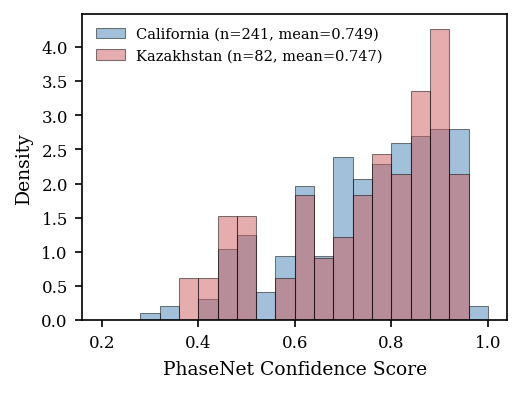

California matched: n=241, mean conf=0.749
Kazakhstan matched: n=82, mean conf=0.747


In [16]:
# Figure 2: Confidence distributions for matched picks
ca_matched = results_df[results_df['matched']]
kz_matched = kz_results_df[kz_results_df['matched']]

ca_conf = ca_matched['confidence'].values
kz_conf = kz_matched['confidence'].values

bins = np.linspace(0.2, 1.0, 21)

fig, ax = plt.subplots(figsize=(3.25, 2.5))

ax.hist(ca_conf, bins=bins, density=True, alpha=0.5,
        color='steelblue', edgecolor='black', linewidth=0.5,
        label=f'California (n={len(ca_conf)}, mean={ca_conf.mean():.3f})')

ax.hist(kz_conf, bins=bins, density=True, alpha=0.5,
        color='indianred', edgecolor='black', linewidth=0.5,
        label=f'Kazakhstan (n={len(kz_conf)}, mean={kz_conf.mean():.3f})')

ax.set_xlabel('PhaseNet Confidence Score')
ax.set_ylabel('Density')
ax.legend(frameon=False, fancybox=False, edgecolor='gray')
ax.tick_params(axis='both', labelsize=8)

plt.tight_layout(pad=0.3)
plt.savefig('figures/fig2_confidence.pdf', bbox_inches='tight')
plt.savefig('figures/fig2_confidence.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'California matched: n={len(ca_conf)}, mean conf={ca_conf.mean():.3f}')
print(f'Kazakhstan matched: n={len(kz_conf)}, mean conf={kz_conf.mean():.3f}')

### Figure 3: Regime Posteriors (Section 5.2)

In [17]:
# Load regime posterior data (exported from main notebook)
import pickle

with open('regime_posteriors.pkl', 'rb') as f:
    regime_data = pickle.load(f)
regime_posteriors = regime_data['regime_posteriors']
week_starts = regime_data['week_starts']
m45_trigger_df = pd.read_csv('m45_trigger_df.csv')
print(f'Regime data: {len(regime_posteriors)} stations, {len(week_starts)} weeks')

Regime data: 11 stations, 209 weeks


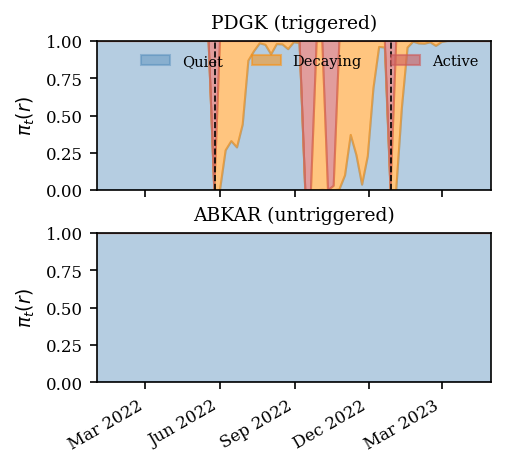

Figure 3 saved.


In [18]:
# Figure 3: Regime posterior stacked area chart
# Two panels: PDGK (triggered) and ABKAR (untriggered)
# Zoomed to 2022-01 to 2023-05 to show regime transitions clearly

import matplotlib.dates as mdates

stations_to_plot = ['PDGK', 'ABKAR']
titles = {'PDGK': 'PDGK (triggered)', 'ABKAR': 'ABKAR (untriggered)'}

# PDGK triggers: M5.1 on 2022-05-26, M5.0 on 2022-12-28
pdgk_triggers = [pd.Timestamp('2022-05-26'), pd.Timestamp('2022-12-28')]

dates = pd.to_datetime(week_starts)

fig, axes = plt.subplots(2, 1, figsize=(3.25, 3.0), sharex=True)

for i, station in enumerate(stations_to_plot):
    ax = axes[i]
    p = np.array(regime_posteriors[station])  # shape (n_weeks, 3): [Quiet, Active, Decaying]

    # Stacked areas: Quiet (bottom), then Decaying, then Active on top
    ax.fill_between(dates, 0, p[:, 0],
                    color='steelblue', alpha=0.4, label='Quiet')
    ax.fill_between(dates, p[:, 0], p[:, 0] + p[:, 2],
                    color='darkorange', alpha=0.5, label='Decaying')
    ax.fill_between(dates, p[:, 0] + p[:, 2], 1.0,
                    color='indianred', alpha=0.6, label='Active')

    # Trigger lines for PDGK
    if station == 'PDGK':
        for t in pdgk_triggers:
            ax.axvline(t, color='black', linestyle='--', linewidth=0.8)

    ax.set_ylabel(r'$\pi_t(r)$')
    ax.set_ylim(0, 1)
    ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-05-01'))
    ax.set_title(titles[station], fontsize=9)
    ax.tick_params(axis='both', labelsize=8)

    if i == 0:
        ax.legend(fontsize=7, frameon=False, loc='upper right', ncol=3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].set_xlabel('')
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout(pad=0.3)
plt.savefig('figures/fig3_regimes.pdf', bbox_inches='tight')
plt.savefig('figures/fig3_regimes.png', bbox_inches='tight', dpi=300)
plt.show()

print('Figure 3 saved.')

## Appendix Figures

Requires `deferral_data.pkl` exported from the main notebook.

In [19]:
# Load deferral analysis data (exported from main notebook)
with open('deferral_data.pkl', 'rb') as f:
    deferral_data = pickle.load(f)
alpha_history = deferral_data['alpha_history']
beta_history = deferral_data['beta_history']
df_aligned = deferral_data['df_aligned']
combined_score_sequence = deferral_data['combined_score_sequence']
print(f'Deferral data: {len(df_aligned)} picks, regimes: {list(beta_history.keys())}')

Deferral data: 190 picks, regimes: ['Q', 'A', 'D']


### Appendix C: Regime Posteriors (all 11 stations)

In [20]:
# Appendix C: Regime posteriors for triggered stations + one representative untriggered
# 4 triggered stations on top, ABKAR (untriggered) on bottom

import matplotlib.dates as mdates

all_stations = sorted(regime_posteriors.keys())
triggered = [s for s in all_stations
             if not np.allclose(np.array(regime_posteriors[s])[:, 0], 1.0, atol=0.05)]
untriggered = [s for s in all_stations if s not in triggered]

# Show triggered + one representative untriggered (ABKAR, also used in Figure 3)
ordered = triggered + ['ABKAR']

n = len(ordered)
fig, axes = plt.subplots(n, 1, figsize=(6.75, 1.2 * n), sharex=True)
dates = pd.to_datetime(week_starts)

for i, station in enumerate(ordered):
    ax = axes[i]
    p = np.array(regime_posteriors[station])
    ax.fill_between(dates, 0, p[:, 0], color='steelblue', alpha=0.4, label='Quiet')
    ax.fill_between(dates, p[:, 0], p[:, 0] + p[:, 2], color='darkorange', alpha=0.5, label='Decaying')
    ax.fill_between(dates, p[:, 0] + p[:, 2], 1.0, color='indianred', alpha=0.6, label='Active')
    ax.set_ylabel(r'$\pi_t(r)$', fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(station, fontsize=8, loc='left')
    ax.tick_params(axis='both', labelsize=7)
    if i == 0:
        ax.legend(fontsize=6, frameon=False, loc='upper right', ncol=3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout(pad=0.3)
plt.savefig('figures/appendix_regimes_all.pdf', bbox_inches='tight')
plt.savefig('figures/appendix_regimes_all.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Triggered: {triggered}')
print(f'Untriggered (not shown): {[s for s in untriggered if s != "ABKAR"]}')

### Appendix D.1: Beta-Bernoulli Convergence

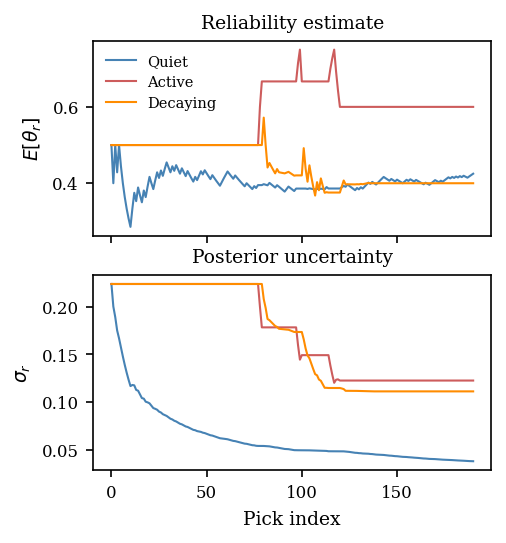

Beta-Bernoulli convergence figure saved.


In [21]:
# Appendix D.1: Beta-Bernoulli posterior evolution over 190 picks
# Two panels: E[theta_r] and sigma_r for each regime

regime_names = {'Q': 'Quiet', 'A': 'Active', 'D': 'Decaying'}
regime_colors = {'Q': 'steelblue', 'A': 'indianred', 'D': 'darkorange'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.25, 3.5), sharex=True)

for r in ['Q', 'A', 'D']:
    alphas = np.array(alpha_history[r])
    betas = np.array(beta_history[r])
    n_steps = len(alphas)
    theta = alphas / (alphas + betas)
    sigma = np.sqrt((alphas * betas) / ((alphas + betas)**2 * (alphas + betas + 1)))
    steps = np.arange(n_steps)

    ax1.plot(steps, theta, color=regime_colors[r], label=regime_names[r], linewidth=1)
    ax2.plot(steps, sigma, color=regime_colors[r], label=regime_names[r], linewidth=1)

ax1.set_ylabel(r'$E[\theta_r]$')
ax1.set_title('Reliability estimate', fontsize=9)
ax1.legend(fontsize=7, frameon=False)
ax1.tick_params(axis='both', labelsize=8)

ax2.set_ylabel(r'$\sigma_r$')
ax2.set_xlabel('Pick index')
ax2.set_title('Posterior uncertainty', fontsize=9)
ax2.tick_params(axis='both', labelsize=8)

plt.tight_layout(pad=0.3)
plt.savefig('figures/appendix_beta_convergence.pdf', bbox_inches='tight')
plt.savefig('figures/appendix_beta_convergence.png', bbox_inches='tight', dpi=300)
plt.show()
print('Beta-Bernoulli convergence figure saved.')

### Appendix D.2: Threshold Sensitivity

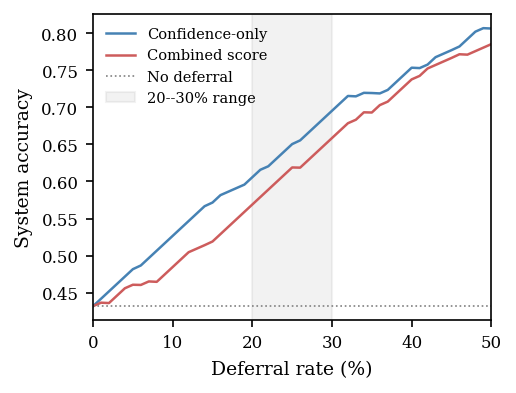

Threshold sensitivity figure saved.


In [22]:
# Appendix D.2: System accuracy vs deferral rate for both methods

n_picks = len(df_aligned)
deferral_rates = np.linspace(0, 0.5, 51)

acc_conf = []
acc_combined = []

conf_sorted = np.sort(df_aligned['confidence'].values)
cs_sorted = np.sort(df_aligned['combined_score'].values)

for rate in deferral_rates:
    n_defer = int(np.round(rate * n_picks))
    if n_defer == 0:
        # No deferral: system accuracy = model accuracy
        base_acc = df_aligned['matched'].mean()
        acc_conf.append(base_acc)
        acc_combined.append(base_acc)
        continue

    # Confidence-only: defer lowest confidence
    conf_thresh = conf_sorted[min(n_defer, n_picks - 1)]
    conf_defer = df_aligned['confidence'] < conf_thresh
    # Handle ties
    if conf_defer.sum() < n_defer:
        tie_mask = (df_aligned['confidence'] == conf_thresh) & (~conf_defer)
        extra = n_defer - conf_defer.sum()
        tie_idx = tie_mask[tie_mask].index[:extra]
        conf_defer.loc[tie_idx] = True
    conf_accept = ~conf_defer
    n_accept = conf_accept.sum()
    if n_accept > 0:
        model_correct = df_aligned.loc[conf_accept, 'matched'].sum()
        analyst_correct = n_defer * 0.95
        acc_conf.append((model_correct + analyst_correct) / n_picks)
    else:
        acc_conf.append(0.95)

    # Combined score: defer lowest combined_score
    cs_thresh = cs_sorted[min(n_defer, n_picks - 1)]
    cs_defer = df_aligned['combined_score'] < cs_thresh
    if cs_defer.sum() < n_defer:
        tie_mask = (df_aligned['combined_score'] == cs_thresh) & (~cs_defer)
        extra = n_defer - cs_defer.sum()
        tie_idx = tie_mask[tie_mask].index[:extra]
        cs_defer.loc[tie_idx] = True
    cs_accept = ~cs_defer
    n_accept_cs = cs_accept.sum()
    if n_accept_cs > 0:
        model_correct_cs = df_aligned.loc[cs_accept, 'matched'].sum()
        analyst_correct_cs = n_defer * 0.95
        acc_combined.append((model_correct_cs + analyst_correct_cs) / n_picks)
    else:
        acc_combined.append(0.95)

fig, ax = plt.subplots(figsize=(3.25, 2.5))
ax.plot(deferral_rates * 100, acc_conf, color='steelblue', label='Confidence-only', linewidth=1.2)
ax.plot(deferral_rates * 100, acc_combined, color='indianred', label='Combined score', linewidth=1.2)
ax.axhline(df_aligned['matched'].mean(), color='gray', linestyle=':', linewidth=0.8, label='No deferral')
ax.axvspan(20, 30, alpha=0.1, color='gray', label='20--30% range')
ax.set_xlabel('Deferral rate (%)')
ax.set_ylabel('System accuracy')
ax.legend(fontsize=7, frameon=False)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlim(0, 50)

plt.tight_layout(pad=0.3)
plt.savefig('figures/appendix_threshold_sweep.pdf', bbox_inches='tight')
plt.savefig('figures/appendix_threshold_sweep.png', bbox_inches='tight', dpi=300)
plt.show()
print('Threshold sensitivity figure saved.')

### Appendix D.4: Capacity Curves

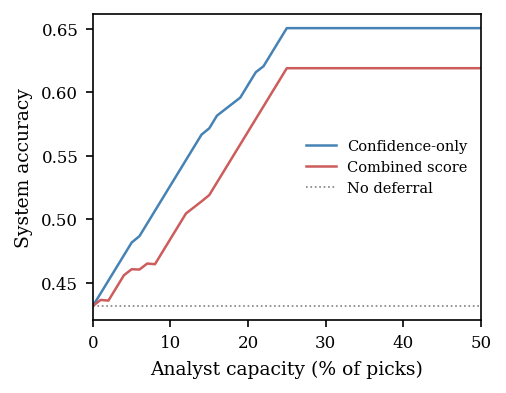

Capacity curves figure saved.


In [23]:
# Appendix D.4: System accuracy vs analyst capacity for both methods
# At fixed 25% deferral rate (48 picks deferred)

n_picks = len(df_aligned)
n_defer = 48

# Identify deferred picks for each method
conf_sorted_idx = df_aligned['confidence'].argsort().values[:n_defer]
cs_sorted_idx = df_aligned['combined_score'].argsort().values[:n_defer]

capacities = np.linspace(0, 0.5, 51)
acc_conf_cap = []
acc_comb_cap = []

for cap in capacities:
    n_review = int(np.round(cap * n_picks))
    n_review = min(n_review, n_defer)

    # Confidence-only: analyst reviews the n_review lowest-confidence deferred picks
    reviewed_conf = conf_sorted_idx[:n_review]
    unreviewed_conf = conf_sorted_idx[n_review:]
    accepted = np.setdiff1d(np.arange(n_picks), conf_sorted_idx)
    model_correct = df_aligned.iloc[accepted]['matched'].sum()
    analyst_correct = n_review * 0.95
    unreviewed_correct = df_aligned.iloc[unreviewed_conf]['matched'].sum()
    acc_conf_cap.append((model_correct + analyst_correct + unreviewed_correct) / n_picks)

    # Combined score: analyst reviews the n_review lowest-score deferred picks
    reviewed_cs = cs_sorted_idx[:n_review]
    unreviewed_cs = cs_sorted_idx[n_review:]
    accepted_cs = np.setdiff1d(np.arange(n_picks), cs_sorted_idx)
    model_correct_cs = df_aligned.iloc[accepted_cs]['matched'].sum()
    analyst_correct_cs = n_review * 0.95
    unreviewed_correct_cs = df_aligned.iloc[unreviewed_cs]['matched'].sum()
    acc_comb_cap.append((model_correct_cs + analyst_correct_cs + unreviewed_correct_cs) / n_picks)

fig, ax = plt.subplots(figsize=(3.25, 2.5))
ax.plot(capacities * 100, acc_conf_cap, color='steelblue', label='Confidence-only', linewidth=1.2)
ax.plot(capacities * 100, acc_comb_cap, color='indianred', label='Combined score', linewidth=1.2)
ax.axhline(df_aligned['matched'].mean(), color='gray', linestyle=':', linewidth=0.8, label='No deferral')
ax.set_xlabel('Analyst capacity (% of picks)')
ax.set_ylabel('System accuracy')
ax.legend(fontsize=7, frameon=False)
ax.tick_params(axis='both', labelsize=8)
ax.set_xlim(0, 50)

plt.tight_layout(pad=0.3)
plt.savefig('figures/appendix_capacity_curves.pdf', bbox_inches='tight')
plt.savefig('figures/appendix_capacity_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print('Capacity curves figure saved.')

### Appendix D.5: Analyst Accuracy Sensitivity

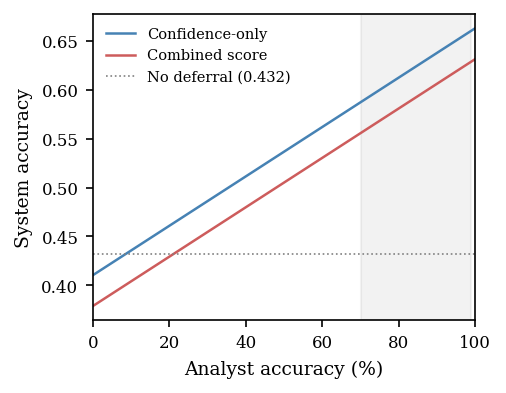

Analyst sensitivity figure saved.


In [24]:
# Appendix D.5: System accuracy vs analyst accuracy (70-99%)
# At fixed 25% deferral rate (48 picks deferred), all deferred picks reviewed

n_picks = len(df_aligned)
n_defer = 48

conf_sorted_idx = df_aligned['confidence'].argsort().values[:n_defer]
cs_sorted_idx = df_aligned['combined_score'].argsort().values[:n_defer]

accepted_conf = np.setdiff1d(np.arange(n_picks), conf_sorted_idx)
accepted_cs = np.setdiff1d(np.arange(n_picks), cs_sorted_idx)

model_correct_conf = df_aligned.iloc[accepted_conf]['matched'].sum()
model_correct_cs = df_aligned.iloc[accepted_cs]['matched'].sum()

analyst_accuracies = np.linspace(0.0, 1.0, 101)
sys_conf = [(model_correct_conf + aa * n_defer) / n_picks for aa in analyst_accuracies]
sys_comb = [(model_correct_cs + aa * n_defer) / n_picks for aa in analyst_accuracies]
baseline = df_aligned['matched'].mean()

fig, ax = plt.subplots(figsize=(3.25, 2.5))
ax.plot(analyst_accuracies * 100, sys_conf, color='steelblue', label='Confidence-only', linewidth=1.2)
ax.plot(analyst_accuracies * 100, sys_comb, color='indianred', label='Combined score', linewidth=1.2)
ax.axhline(baseline, color='gray', linestyle=':', linewidth=0.8, label=f'No deferral ({baseline:.3f})')
ax.axvspan(70, 99, alpha=0.1, color='gray')
ax.set_xlabel('Analyst accuracy (%)')
ax.set_ylabel('System accuracy')
ax.set_xlim(0, 100)
ax.legend(fontsize=7, frameon=False)
ax.tick_params(axis='both', labelsize=8)

plt.tight_layout(pad=0.3)
plt.savefig('figures/appendix_analyst_sensitivity.pdf', bbox_inches='tight')
plt.savefig('figures/appendix_analyst_sensitivity.png', bbox_inches='tight', dpi=300)
plt.show()
print('Analyst sensitivity figure saved.')